# this hands-on is mainly practice the underfitting scenario :

L1-regularization (Lasso, LassoCV - CrossValidation), 
Pipeline : PolynomialFeatures, StandardScaler

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv(r"E:\Machine Learning\Linear Regression\source\dramatic_underfit_dataset_10000x5.csv")

In [54]:
df.head()

,effect_due_to_family_history,effect_due_to_smoking,effect_due_to_drinking,effect_due_to_sleeplessness,recovery rate
0,7.739560,7.207284,7.407728,3.471255,0.000000
1,4.388784,7.112378,9.958065,4.210164,0.000000
2,8.585979,2.026950,0.409773,9.846994,0.000000
3,6.973680,0.366554,2.449194,0.841941,75.456529
4,0.941773,3.037995,5.977407,1.116511,62.750759


In [5]:
df.corr()

,effect_due_to_family_history,effect_due_to_smoking,effect_due_to_drinking,effect_due_to_sleeplessness,recovery rate
effect_due_to_family_history,1.000000,-0.003246,-0.005441,0.034638,-0.138181
effect_due_to_smoking,-0.003246,1.000000,-0.005421,-0.001059,-0.691835
effect_due_to_drinking,-0.005441,-0.005421,1.000000,0.006792,-0.107481
effect_due_to_sleeplessness,0.034638,-0.001059,0.006792,1.000000,-0.542049
recovery rate,-0.138181,-0.691835,-0.107481,-0.542049,1.000000


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [15]:
X = df.drop('recovery rate', axis = 1)
Y = df['recovery rate']

In [16]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size = 0.2,
    random_state = 42
)

In [17]:
ols = LinearRegression()
ols.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[-1.03,-5.78,-0.93,-4.52]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['effect_due_to_family_history','effect_due_to_smoking', 'effect_due_to_drinking','effect_due_to_sleeplessness']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,81.22
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [18]:
train_pred = ols.predict(x_train) # passing the same trained value to check the learning
test_pred = ols.predict(x_test) # now, testing the model by new vaules

In [19]:
train_pred

array([53.93007082, -1.62001967, 16.75152489, ..., 33.01664289,
       46.45501249, 61.12972181], shape=(8000,))

In [20]:
test_pred

array([42.3570695 ,  4.61726845,  9.75421649, ..., 33.06920159,
       -4.36595971, 12.91386673], shape=(2000,))

In [21]:
print('Train R2:', r2_score(y_train, train_pred))
print('Test R2:', r2_score(y_test, test_pred))
print('Train MSE:', mean_squared_error(y_train, train_pred))
print('Test MSE:', mean_squared_error(y_test, test_pred))

Train R2: 0.8019788169065679
Test R2: 0.7901358896269034
Train MSE: 115.79810708399705
Test MSE: 117.68462541306005


In [22]:
# Lasso regression:

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Lasso, LassoCV
from sklearn.pipeline import Pipeline

In [23]:
poly = PolynomialFeatures(
    degree = 2,
    include_bias = False
)

In [24]:
lasso_pipeline = Pipeline([
    ("poly", poly),
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha = 1.0)) #hyperparameter tuning
])

In [25]:
lasso_pipeline.fit(
    x_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('poly', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['effect_due_to_family_history','effect_due_to_smoking', 'effect_due_to_drinking','effect_due_to_sleeplessness']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [26]:
train_pred_las = lasso_pipeline.predict(x_train)
test_pred_las = lasso_pipeline.predict(x_test)

In [27]:
# lasso

print('Train R2:', r2_score(y_train, train_pred_las))
print('Test R2:', r2_score(y_test, test_pred_las))
print('Train MSE:', mean_squared_error(y_train, train_pred_las))
print('Test MSE:', mean_squared_error(y_test, test_pred_las))

Train R2: 0.8651186660650301
Test R2: 0.8569309271622533
Train MSE: 78.87541578450484
Test MSE: 80.22824967628407


In [28]:
# ols, normal model

print('Train R2:', r2_score(y_train, train_pred))
print( 'Test R2:', r2_score(y_test, test_pred))
print('Train MSE:', mean_squared_error(y_train, train_pred))
print('Test MSE:', mean_squared_error(y_test, test_pred))

Train R2: 0.8019788169065679
Test R2: 0.7901358896269034
Train MSE: 115.79810708399705
Test MSE: 117.68462541306005


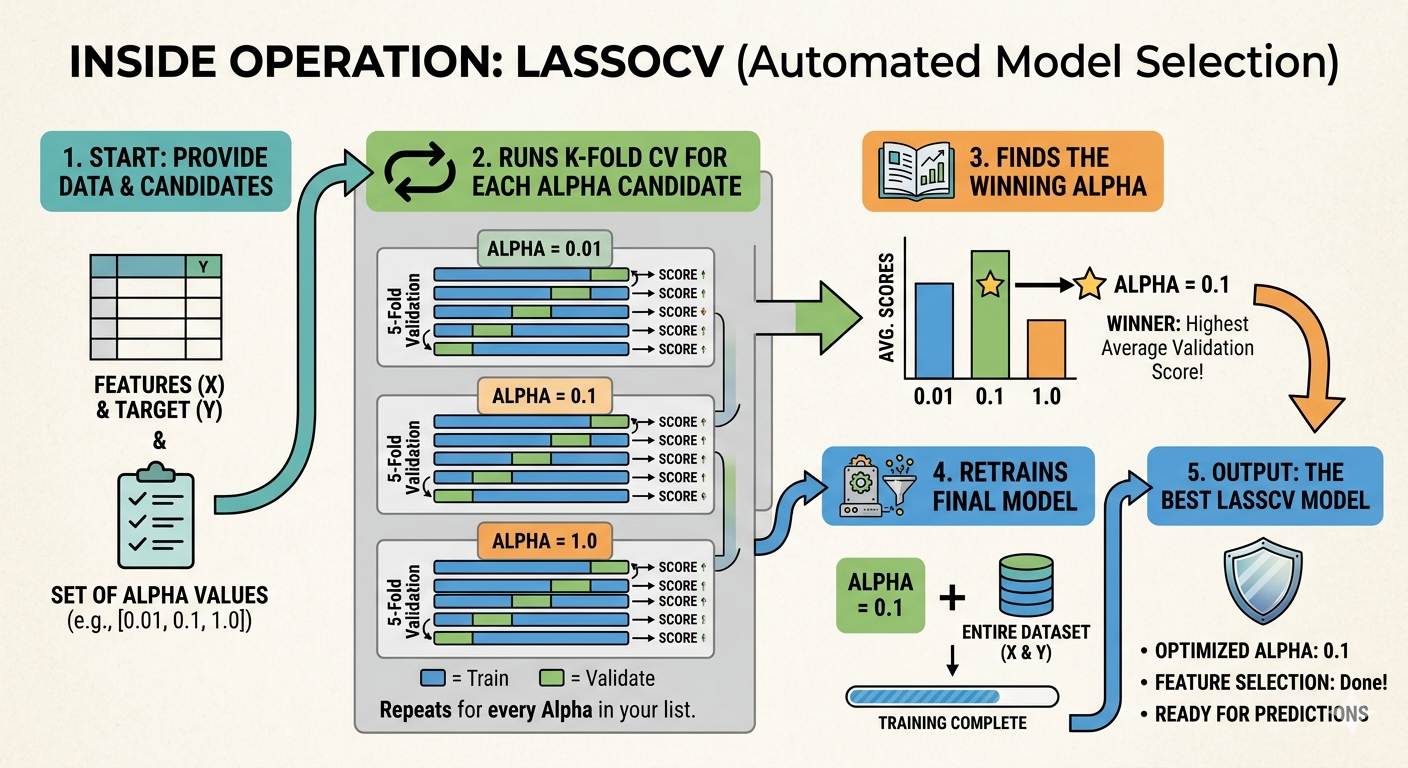

In [29]:
# LassoCV - cross validation : by default uses 5 fold
# this find the best alpha value by iteration process.
# again re-train the model with that alpha value ie, which is find in the iteration process.
# and it will fit the model and ready for predictions

# disadvantages:
# time-consuming - slow (takes time to iterate if the featues are more in dataset)

# refer this man:
from IPython.display import Image, display
img = r"E:\Machine Learning\My notes\LassoCV.png"
display(Image(filename = img, width = 400))


In [30]:
poly = PolynomialFeatures(
    degree = 3,
    include_bias = False
)

In [31]:
lasso_pipeline_cv = Pipeline([
    ("poly", poly),
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(
        cv = 5,
        random_state = 42,
        max_iter = 10000
    )
    )
])

In [32]:
lasso_pipeline_cv.fit(
    x_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('poly', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['effect_due_to_family_history','effect_due_to_smoking', 'effect_due_to_drinking','effect_due_to_sleeplessness']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",3
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [33]:
train_pred_las_cv = lasso_pipeline_cv.predict(x_train)
test_pred_las_cv = lasso_pipeline_cv.predict(x_test)

In [34]:
# lassoCV

print('Train R2:', r2_score(y_train, train_pred_las_cv))
print('Test R2:', r2_score(y_test, test_pred_las_cv))
print('Train MSE:', mean_squared_error(y_train, train_pred_las_cv))
print('Test MSE:', mean_squared_error(y_test, test_pred_las_cv))

Train R2: 0.9746827277628475
Test R2: 0.9732561955006072
Train MSE: 14.804942359167915
Test MSE: 14.997012157227944


In [35]:
lasso_pipeline_cv.named_steps['lasso'].alpha_

np.float64(0.01673488870630768)

In [36]:
# compare all:

In [37]:
# ols, normal model

print('Train R2:', r2_score(y_train, train_pred))
print( 'Test R2:', r2_score(y_test, test_pred))
print('Train MSE:', mean_squared_error(y_train, train_pred))
print('Test MSE:', mean_squared_error(y_test, test_pred))

Train R2: 0.8019788169065679
Test R2: 0.7901358896269034
Train MSE: 115.79810708399705
Test MSE: 117.68462541306005


In [38]:
# lasso - alpha - 1000

print('Train R2:', r2_score(y_train, train_pred_las))
print('Test R2:', r2_score(y_test, test_pred_las))
print('Train MSE:', mean_squared_error(y_train, train_pred_las))
print('Test MSE:', mean_squared_error(y_test, test_pred_las))

Train R2: 0.8651186660650301
Test R2: 0.8569309271622533
Train MSE: 78.87541578450484
Test MSE: 80.22824967628407


In [39]:
# lassoCV : iteration - 10000, cv = 5

print('Train R2:', r2_score(y_train, train_pred_las_cv))
print('Test R2:', r2_score(y_test, test_pred_las_cv))
print('Train MSE:', mean_squared_error(y_train, train_pred_las_cv))
print('Test MSE:', mean_squared_error(y_test, test_pred_las_cv))

Train R2: 0.9746827277628475
Test R2: 0.9732561955006072
Train MSE: 14.804942359167915
Test MSE: 14.997012157227944
